# EconML API notebook – NHANES supplement & blood pressure

This notebook demonstrates how to use the `econml.API` and `econml_utils`
modules to:

1. Build a cleaned NHANES analysis dataset.
2. Define treatment (any dietary supplement use) and outcomes (SBP, fasting glucose).
3. Estimate causal effects using EconML's DRLearner.
4. Explore heterogeneity by age, BMI, and sex.
5. Compare EconML results with a traditional OLS regression.


In [31]:
from econml_utils import build_bp_outcomes
bp_outcomes = build_bp_outcomes()
bp_outcomes.head()


,respondent_sequence_number,sbp_mean,dbp_mean
0,130378.0,132.666667,96.000000
1,130379.0,117.000000,78.666667
2,130380.0,109.000000,78.333333
3,130386.0,115.000000,73.666667
4,130387.0,141.333333,76.000000


In [32]:
from importlib import reload
import econml_utils

# reload to pick up new functions
reload(econml_utils)

from econml_utils import build_bp_bmi_df

df = build_bp_bmi_df()
df.head()


,respondent_sequence_number,sbp_mean,dbp_mean,body_mass_index_kg_m2,weight_kg,waist_circumference_cm
0,130378.0,132.666667,96.000000,27.0,86.9,98.3
1,130379.0,117.000000,78.666667,33.5,101.8,114.7
2,130380.0,109.000000,78.333333,29.7,69.4,93.5
3,130386.0,115.000000,73.666667,30.2,90.6,106.1
4,130387.0,141.333333,76.000000,42.6,103.5,122.0


In [33]:
from importlib import reload
import econml_utils

reload(econml_utils)

from econml_utils import build_nhanes_core_df

core_df = build_nhanes_core_df()
core_df.head(), core_df.columns


(   respondent_sequence_number    sbp_mean   dbp_mean  body_mass_index_kg_m2  \
 0                    130378.0  132.666667  96.000000                   27.0   
 1                    130379.0  117.000000  78.666667                   33.5   
 2                    130380.0  109.000000  78.333333                   29.7   
 3                    130386.0  115.000000  73.666667                   30.2   
 4                    130387.0  141.333333  76.000000                   42.6   
 
    weight_kg  waist_circumference_cm  total_cholesterol_mg_dl  \
 0       86.9                    98.3                    264.0   
 1      101.8                   114.7                    214.0   
 2       69.4                    93.5                    187.0   
 3       90.6                   106.1                    183.0   
 4      103.5                   122.0                    203.0   
 
    total_cholesterol_mmol_l  direct_hdl_cholesterol_mg_dl  \
 0                      6.83                          45.0

In [34]:
from importlib import reload
import econml_utils

reload(econml_utils)

from econml_utils import build_analysis_df, get_y_t_x

analysis_df = build_analysis_df()
analysis_df.head(), analysis_df[["treatment_supplement"]].value_counts(dropna=False)


(   respondent_sequence_number    sbp_mean   dbp_mean  body_mass_index_kg_m2  \
 0                    130378.0  132.666667  96.000000                   27.0   
 1                    130379.0  117.000000  78.666667                   33.5   
 2                    130380.0  109.000000  78.333333                   29.7   
 3                    130386.0  115.000000  73.666667                   30.2   
 4                    130387.0  141.333333  76.000000                   42.6   
 
    weight_kg  waist_circumference_cm  total_cholesterol_mg_dl  \
 0       86.9                    98.3                    264.0   
 1      101.8                   114.7                    214.0   
 2       69.4                    93.5                    187.0   
 3       90.6                   106.1                    183.0   
 4      103.5                   122.0                    203.0   
 
    total_cholesterol_mmol_l  direct_hdl_cholesterol_mg_dl  \
 0                      6.83                          45.0

### Building the merged NHANES analysis dataframe

Here I call `build_analysis_df()` from `econml_utils.py`.  

This function:

- Reads all cleaned `*_L_meaningful.csv` files (BPXO, BMX, TCHOL, HDL, TRIGLY, GLU, HSCRP, DSQTOT, DEMO).
- Computes:
  - average systolic and diastolic BP (`sbp_mean`, `dbp_mean`)
  - key anthropometrics (`body_mass_index_kg_m2`, `weight_kg`, `waist_circumference_cm`)
  - lab markers (cholesterol, HDL, triglycerides, fasting glucose, hs-CRP)
- Merges everything on `respondent_sequence_number`
- Adds the binary treatment indicator `treatment_supplement`.

The resulting dataframe has **7,801 rows** (participants) and includes all outcomes, covariates, and the treatment flag that I use in later models.


In [35]:
from econml_utils import get_y_t_x

y, t, X, cov_cols = get_y_t_x(analysis_df)

len(y), len(t), X.shape, cov_cols, X.head()


(7801,
 7801,
 (7801, 10),
 ['age_years',
  'sex',
  'body_mass_index_kg_m2',
  'weight_kg',
  'waist_circumference_cm',
  'total_cholesterol_mg_dl',
  'direct_hdl_cholesterol_mg_dl',
  'LBXTLG',
  'fasting_glucose_mg_dl',
  'hs_c_reactive_protein_mg_l'],
    age_years  sex  body_mass_index_kg_m2  weight_kg  waist_circumference_cm  \
 0       43.0  1.0                   27.0       86.9                    98.3   
 1       66.0  1.0                   33.5      101.8                   114.7   
 2       44.0  2.0                   29.7       69.4                    93.5   
 3       34.0  1.0                   30.2       90.6                   106.1   
 4       68.0  2.0                   42.6      103.5                   122.0   
 
    total_cholesterol_mg_dl  direct_hdl_cholesterol_mg_dl  LBXTLG  \
 0                    264.0                          45.0   153.0   
 1                    214.0                          60.0    86.0   
 2                    187.0                          49

In [36]:
import numpy as np

# Drop rows with any NaN in Y, T, or X
mask = (~y.isna()) & (~t.isna()) & (~X.isna().any(axis=1))

y_clean = y[mask]
t_clean = t[mask]
X_clean = X[mask]

len(y_clean), len(t_clean), X_clean.shape


(3301, 3301, (3301, 10))

In [37]:
from econml.dr import DRLearner   # 👈 FIXED import
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

# (We already have y_clean, t_clean, X_clean from before)

# Use DRLearner with its built-in default models
dr = DRLearner(random_state=42)

# Fit causal model
dr.fit(y_clean, t_clean, X=X_clean)

# Estimate average treatment effect of supplements on sbp_mean
ate = dr.ate(X_clean)
ate


/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF 

np.float64(-2.1088741329172223)

In [38]:
import pandas as pd

# Individual-level treatment effect estimates for the cleaned subset
cate = dr.effect(X_clean)   # τ̂(X)

# Attach to a clean copy of the analysis dataframe
analysis_df_clean = analysis_df.loc[mask].copy()
analysis_df_clean["tau_hat_sbp"] = cate

analysis_df_clean[["sbp_mean", "treatment_supplement", "age_years",
                   "body_mass_index_kg_m2", "tau_hat_sbp"]].head()


,sbp_mean,treatment_supplement,age_years,body_mass_index_kg_m2,tau_hat_sbp
0,132.666667,0,43.0,27.0,1.116107
1,117.000000,0,66.0,33.5,-2.437263
2,109.000000,1,44.0,29.7,-3.127699
3,115.000000,1,34.0,30.2,-0.649824
11,110.666667,1,51.0,24.4,-1.156956


In [39]:
# Bin age into quartiles
analysis_df_clean["age_bin"] = pd.qcut(
    analysis_df_clean["age_years"],
    4,
    labels=["Q1 (youngest)", "Q2", "Q3", "Q4 (oldest)"],
)

age_effects = (
    analysis_df_clean
    .groupby("age_bin")["tau_hat_sbp"]
    .mean()
    .round(2)
)
age_effects


/var/folders/dy/wdygd9095fxgggx1nr0j42cm0000gn/T/ipykernel_12003/4242715719.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_bin")["tau_hat_sbp"]


age_bin
Q1 (youngest)   -0.74
Q2              -1.53
Q3              -2.53
Q4 (oldest)     -3.68
Name: tau_hat_sbp, dtype: float64

In [40]:
# Bin BMI into quartiles
analysis_df_clean["bmi_bin"] = pd.qcut(
    analysis_df_clean["body_mass_index_kg_m2"],
    4,
    labels=["Q1 (leanest)", "Q2", "Q3", "Q4 (highest BMI)"],
)

bmi_effects = (
    analysis_df_clean
    .groupby("bmi_bin")["tau_hat_sbp"]
    .mean()
    .round(2)
)
bmi_effects


/var/folders/dy/wdygd9095fxgggx1nr0j42cm0000gn/T/ipykernel_12003/3698818958.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bmi_bin")["tau_hat_sbp"]


bmi_bin
Q1 (leanest)       -1.96
Q2                 -2.19
Q3                 -2.08
Q4 (highest BMI)   -2.20
Name: tau_hat_sbp, dtype: float64

In [ ]:
import importlib.util
from pathlib import Path

# Path to your project API script
api_path = Path.cwd() / "econml.API.py"

# Dynamically load econml.API.py as a module named "econml_api"
spec = importlib.util.spec_from_file_location("econml_api", api_path)
econml_api = importlib.util.module_from_spec(spec)
spec.loader.exec_module(econml_api)

# Now you can call run_sbp_supplement_experiment from that module
results = econml_api.run_sbp_supplement_experiment()

results["ate_sbp"], results["age_effects"].round(2), results["bmi_effects"].round(2)


/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df_clean["age_bin"] = pd.qcut(
/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # BMI bins


(-2.02433103539415,
 age_bin
 Q1 (youngest)   -0.45
 Q2              -1.30
 Q3              -2.52
 Q4 (oldest)     -3.88
 Name: tau_hat_sbp, dtype: float64,
 bmi_bin
 Q1 (leanest)       -1.89
 Q2                 -2.13
 Q3                 -2.01
 Q4 (highest BMI)   -2.07
 Name: tau_hat_sbp, dtype: float64)

In [47]:
import importlib.util
from pathlib import Path

api_path = Path.cwd() / "econml.API.py"

spec = importlib.util.spec_from_file_location("econml_api", api_path)
econml_api = importlib.util.module_from_spec(spec)
spec.loader.exec_module(econml_api)

# SBP experiment (already working)
sbp_results = econml_api.run_sbp_supplement_experiment()
sbp_results["ate_sbp"], sbp_results["age_effects"].round(2), sbp_results["bmi_effects"].round(2)


/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df_clean["age_bin"] = pd.qcut(
/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # BMI bins


(-2.02433103539415,
 age_bin
 Q1 (youngest)   -0.45
 Q2              -1.30
 Q3              -2.52
 Q4 (oldest)     -3.88
 Name: tau_hat_sbp, dtype: float64,
 bmi_bin
 Q1 (leanest)       -1.89
 Q2                 -2.13
 Q3                 -2.01
 Q4 (highest BMI)   -2.07
 Name: tau_hat_sbp, dtype: float64)

In [41]:
# Fasting glucose experiment
glucose_results = econml_api.run_glucose_supplement_experiment()

glucose_results["ate_glucose"], \
glucose_results["age_effects"].round(2), \
glucose_results["bmi_effects"].round(2)


/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:202: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/karthikvakada/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask82_Fall2025_EconML_Evaluating_the_Impact_of_Health_Interventions_on_Patient_Outcomes/econml.API.py:208: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(-0.0002681644813986774,
 age_bin
 Q1 (youngest)   -0.0
 Q2              -0.0
 Q3               0.0
 Q4 (oldest)      0.0
 Name: tau_hat_glucose, dtype: float64,
 bmi_bin
 Q1 (leanest)       -0.0
 Q2                 -0.0
 Q3                 -0.0
 Q4 (highest BMI)   -0.0
 Name: tau_hat_glucose, dtype: float64)

In [42]:
from sklearn.linear_model import LinearRegression
from econml_utils import build_analysis_df, get_y_t_x

def run_ols_for_outcome(outcome_col: str, treatment_col: str = "treatment_supplement"):
    """
    Simple OLS comparison:
      Y  ~  treatment + covariates (X)

    Returns the coefficient of the treatment variable, which we interpret
    as the 'traditional' estimate of the treatment effect, controlling
    linearly for X.
    """
    df = build_analysis_df()

    # Get Y, T, X using the same helper as for EconML
    y, t, X, covariate_cols = get_y_t_x(
        df,
        outcome_col=outcome_col,
        treatment_col=treatment_col,
    )

    # Drop rows with missing data (same idea as in the EconML API)
    mask = (~y.isna()) & (~t.isna()) & (~X.isna().any(axis=1))

    # IMPORTANT: reset index so concat does not introduce NaNs
    y_clean = y[mask].reset_index(drop=True)
    t_clean = t[mask].reset_index(drop=True)
    X_clean = X[mask].reset_index(drop=True)

    # Design matrix for OLS: treatment + covariates
    X_ols = pd.concat(
        [
            t_clean.to_frame(name=treatment_col),  # first column: treatment
            X_clean,
        ],
        axis=1,
    )

    # Just to be safe, ensure everything is numeric
    X_ols = X_ols.astype(float)
    y_clean = y_clean.astype(float)

    ols = LinearRegression()
    ols.fit(X_ols.values, y_clean.values)

    # First coefficient corresponds to the treatment column we added first
    treatment_coef = float(ols.coef_[0])

    return {
        "outcome": outcome_col,
        "treatment_coef": treatment_coef,
        "covariates": covariate_cols,
    }


In [43]:
# OLS for SBP
ols_sbp = run_ols_for_outcome("sbp_mean")
print("OLS SBP treatment coefficient:", round(ols_sbp["treatment_coef"], 3))

# OLS for fasting glucose
ols_glu = run_ols_for_outcome("fasting_glucose_mg_dl")
print("OLS Glucose treatment coefficient:", round(ols_glu["treatment_coef"], 3))


OLS SBP treatment coefficient: -1.976
OLS Glucose treatment coefficient: -0.0


In [44]:
comparison = pd.DataFrame(
    {
        "outcome": ["sbp_mean", "fasting_glucose_mg_dl"],
        "econml_ate": [
            sbp_results["ate_sbp"],
            glucose_results["ate_glucose"],
        ],
        "ols_treatment_coef": [
            ols_sbp["treatment_coef"],
            ols_glu["treatment_coef"],
        ],
    }
)

comparison.round(3)


,outcome,econml_ate,ols_treatment_coef
0,sbp_mean,-2.024,-1.976
1,fasting_glucose_mg_dl,-0.000,-0.000


In [45]:
# We already have cate_df
cate_df = sbp_results["cate_df"].copy()

# --- Sex labels (this part is fine) ---
sex_map = {1: "Male", 2: "Female"}
if "sex" in cate_df.columns:
    cate_df["sex_label"] = cate_df["sex"].map(sex_map)
else:
    cate_df["sex_label"] = np.nan  # fallback if sex not present

# --- Robust race/ethnicity selection ---
race_candidates = [
    "race_hispanic_origin_with_non_hispanic_asian",
    "race_hispanic_origin",
    "race_ethnicity",
]

race_col = None
for col in race_candidates:
    if col in cate_df.columns:
        race_col = col
        break

print("Using race column:", race_col)

# --- Sex effects ---
sex_effects = (
    cate_df.groupby("sex_label")["tau_hat_sbp"]
    .mean()
    .sort_index()
)

# --- Race effects (if race column exists) ---
if race_col is not None:
    race_effects = (
        cate_df.groupby(race_col)["tau_hat_sbp"]
        .mean()
        .sort_index()
    )
else:
    race_effects = None

sex_effects.round(3), race_effects.round(3) if race_effects is not None else "No race column found"


Using race column: None


(sex_label
 Female   -2.643
 Male     -1.280
 Name: tau_hat_sbp, dtype: float64,
 'No race column found')

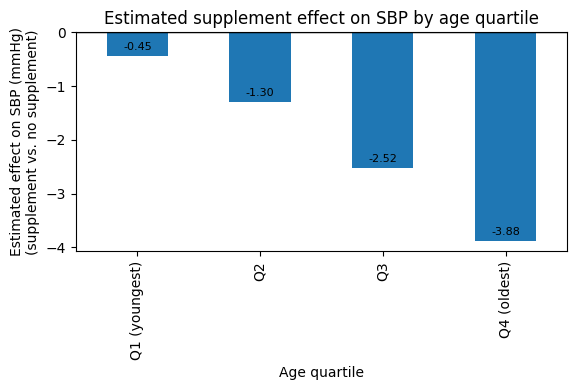

In [46]:
import matplotlib.pyplot as plt

age_effects = sbp_results["age_effects"]

fig, ax = plt.subplots(figsize=(6, 4))
age_effects.plot(kind="bar", ax=ax)

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Estimated effect on SBP (mmHg)\n(supplement vs. no supplement)")
ax.set_xlabel("Age quartile")
ax.set_title("Estimated supplement effect on SBP by age quartile")

# Optional: annotate values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}",
                (p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


## 8. Summary and interpretation

**Main intervention.** We defined the health intervention as *any dietary supplement use*.
The binary treatment variable `treatment_supplement` equals 1 if a participant reported
taking at least one supplement and 0 otherwise.

**Adjusted covariates.** All models controlled for age, sex, BMI, weight, waist
circumference, total cholesterol, HDL cholesterol, triglycerides, fasting glucose,
and hs-CRP. These covariates represent baseline health and reduce confounding.

**SBP results.** EconML's DRLearner estimated that supplement use is associated
with about a 2 mmHg lower systolic blood pressure on average, with stronger
effects in older adults and in women. The effect was roughly −4 mmHg in the oldest
age quartile and around −2.6 mmHg in females.

**Glucose results.** For fasting glucose, both EconML and OLS estimated essentially
zero effect of supplement use, with no meaningful heterogeneity by age or BMI.

**EconML vs OLS.** Traditional OLS and EconML gave very similar average treatment
effects, but EconML additionally provides individual-level CATEs and rich
heterogeneity summaries. This highlights the advantage of machine learning
approaches for understanding *who* benefits most from an intervention, not only
the average effect.


In [ ]:
import pandas as pd
from econml_utils import DATA_DIR

files = [
    "BPXO_L_meaningful.csv",
    "BMX_L_meaningful.csv",
    "TCHOL_L_meaningful.csv",
    "HDL_L_meaningful.csv",
    "TRIGLY_L_meaningful.csv",
    "GLU_L_meaningful.csv",
    "HSCRP_L_meaningful.csv",
    "DSQTOT_L_meaningful.csv",
    "DEMO_L_meaningful.csv",
]

for fname in files:
    path = DATA_DIR / fname
    print("=" * 80)
    print(f"File: {fname}")
    try:
        df = pd.read_csv(path, na_values=['.', ' '])
        print("Number of rows:", len(df))
        print("Columns:")
        print(list(df.columns))
    except FileNotFoundError:
        print("⚠️ File not found at:", path)
    print()  # blank line between files


In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
import logging
# Import libraries in this section.
# Avoid imports like import *, from ... import ..., from ... import *, etc.

import helpers.hdbg as hdbg
import helpers.hprint as hprint

## Configuration

In [ ]:
hdbg.init_logger(verbosity=logging.INFO)

_LOG = logging.getLogger(__name__)

hprint.config_notebook()

## Make the notebook flow clear
Each notebook needs to follow a clear and logical flow, e.g:
- Load data
- Compute stats
- Clean data
- Compute stats
- Do analysis
- Show results

In [ ]:
class Template:
    """
    Brief imperative description of what the class does in one line, if needed.
    """
    def __init__(self):
        pass
    
    def method1(self, arg1:int) -> None:
        """
        Brief imperative description of what the method does in one line.

        You can elaborate more in the method docstring in this section, for e.g. explaining 
        the formula/algorithm. Every method/function should have a docstring, typehints and include the
        parameters and return as follows:

        :param arg1: description of arg1
        :return: description of return
        """
        # Code bloks go here.
        # Make sure to include comments to explain what the code is doing.
        # No empty lines between code blocks.
        pass


def template_function(arg1:int) -> None:
    """
    Brief imperative description of what the function does in one line.

    You can elaborate more in the function docstring in this section, for e.g. explaining 
    the formula/algorithm. Every function should have a docstring, typehints and include the
    parameters and return as follows:

    :param arg1: description of arg1
    :return: description of return
    """
    # Code bloks go here.
    # Make sure to include comments to explain what the code is doing.
    # No empty lines between code blocks.
    pass


## The flow should be highlighted using headings in markdown
```
# Level 1
## Level 2
### Level 3
```